# Preprocessing and Dataloader creation
Test out preprocessing here<br>
Make own Dataset work with Dataloaders<br>
exploit HDF5 properties

## Inputs
Dataset that is freshly created by simulation

## Preprocessing
1. Extract ball posiiton (Ground-truth file)
2. Extract ball position (try with active regions)
3. cut ROI
4. save into one Big hdf5 file
5. include ground-truth into hdf5 file
6. save dataset stats (training-samples, avg-length etc.)

In [1]:
import h5py
import numpy as np
import torch
import pandas as pd
import sys
import matplotlib.pyplot as plt
sys.path.append("../src/utils/")
import eventIO
import event_represenations

In [78]:
path = "/data/lkolmar/datasets/topspin_fit_to_max/"
cfg = pd.read_csv(path + "config/simulation.csv")
# print(cfg.iloc[:5])
sample = cfg.iloc[1458]
print(sample)
print(sample["path"])

index                         1458
rotation_x              -59.487179
rotation_y                10.25641
rotation_z                6.153846
initial_rot_x                  0.0
initial_rot_y                  0.0
initial_rot_z                  0.0
finished                      True
path             data/01458/01458_
Name: 1458, dtype: object
data/01458/01458_


In [79]:
metadata = pd.read_csv(path + sample["path"] + "metadata.csv")
events = eventIO.load_hdf5(path + sample["path"] + "events.hdf5")
coords = pd.read_csv(path + sample["path"] + "ball_coords.csv")
print(coords)

     frame     screen_x    screen_y
0        0  1240.000153  360.000043
1        1  1237.600174  360.000043
2        2  1235.200119  360.000043
3        3  1232.800140  360.000043
4        4  1230.400162  360.000043
..     ...          ...         ...
496    496    49.600005  360.000043
497    497    47.199965  360.000043
498    498    44.799924  360.000043
499    499    42.399883  360.000043
500    500    39.999962  360.000043

[501 rows x 3 columns]


In [83]:
def get_fraction(t, t0, t1):
    """    Calculate the fraction of time t within the interval [t0, t1].
    Args:
        t (float): The time to evaluate.
        t0 (float): The start of the interval.
        t1 (float): The end of the interval.
    """
    return (t - t0) / (t1 - t0)

In [80]:
frame = 400
total_frames = metadata["total_frames"].values[0]
total_time_us = metadata["video_length"].values[0] * 1e6  # convert to microseconds
print(f"Total frames: {total_frames}, Total time: {total_time_us} us")
t0 = events.ts.min()
t1 = events.ts.max()
frame_t = (total_time_us) / total_frames
idxs_frame = np.where((events.ts >= t0 + frame * frame_t) & (events.ts < t0 + (frame + 1) * frame_t))[0]
xs,ys,ts,ps = events.x[idxs_frame], events.y[idxs_frame], events.ts[idxs_frame], events.p[idxs_frame]
ball_x = coords["screen_x"][frame]
ball_y = coords["screen_y"][frame]
print(events.ts.min())

Total frames: 500, Total time: 148761.0 us
2


In [95]:
# Position can be calulated from timestamps
time_window = 1000  # in microseconds
start = 70000
end = start + time_window
idxs = np.where((events.ts >= start) & (events.ts < end))[0]
frame_idx_before = int(start // frame_t)
frame_idx_after = min(frame_idx_before + 1, total_frames - 1)
fraction = get_fraction(start, (frame_idx_before * frame_t) + t0, (frame_idx_after * frame_t) + t0)
print(f"Fraction of time: {fraction:.2f} (between frames {frame_idx_before} and {frame_idx_after})")
ball_x = coords["screen_x"][frame_idx_before] + fraction * (coords["screen_x"][frame_idx_after] - coords["screen_x"][frame_idx_before])
ball_y = coords["screen_y"][frame_idx_before] + fraction * (coords["screen_y"][frame_idx_after] - coords["screen_y"][frame_idx_before])
print(f"Ball position at time {start} us: ({ball_x}, {ball_y})")
idxs_frame = np.where((events.ts >= start) & (events.ts < end))[0]

Fraction of time: 0.27 (between frames 235 and 236)
Ball position at time 70000 us: (675.3520537864193, 360.00004291534424)


In [98]:
# cut out ROI
xs,ys,ts,ps = events.x[idxs_frame], events.y[idxs_frame], events.ts[idxs_frame], events.p[idxs_frame]
roi_size = 100
idx = np.where((xs >= ball_x - roi_size // 2) & (xs < ball_x + roi_size // 2) &
               (ys >= ball_y - roi_size // 2) & (ys < ball_y + roi_size // 2))
xs, ys, ts, ps = xs[idx] - int(np.ceil(ball_x - roi_size // 2)), ys[idx] - int(np.ceil(ball_y - roi_size // 2)), ts[idx], ps[idx]
print(f"ROI: {xs.shape[0]} events")
print(f"With shape: {np.max(xs)} x {np.max(ys)} px")

ROI: 6352 events
With shape: 99 x 93 px


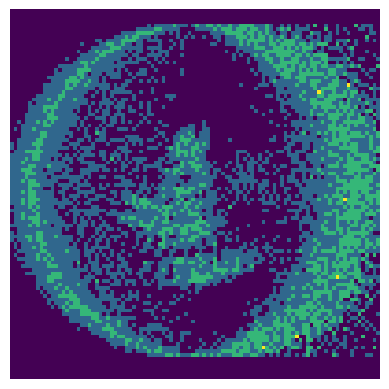

In [99]:
plt.imshow(event_represenations.events_to_image(xs, ys, ts, ps, sensor_size=(roi_size, roi_size)))
# plt.scatter(ball_x, ball_y, c='r', s=10)
plt.axis('off')
plt.show()